# Actividad 1 – Regresión Lineal
## Dataset: Energy Efficiency Data

### Objetivo
El objetivo de esta actividad es aplicar un modelo de **regresión lineal** para predecir una **variable continua** asociada al consumo energético de edificios, a partir de variables predictoras relacionadas con características geométricas y de diseño.

En particular, se busca predecir la **carga de calefacción (`Heating_Load`)** utilizando las demás variables del dataset.



## 1. Preparación y organización de los datos

###1.1 Carga del dataset


In [1]:
import pandas as pd
import numpy as np

# Cargar el dataset
df = pd.read_csv("energy_efficiency_data.csv")

# Ver las primeras filas
df.head()


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Inspección general de los datos

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


Definición de variables
Variable objetivo (y): Heating_Load
Variables predictoras (X): características geométricas y de diseño del edificio.

In [3]:
# Variable objetivo
y = df["Heating_Load"]

# Variables predictoras
X = df.drop(columns=["Heating_Load", "Cooling_Load"])


In [4]:

# Ver valores nulos
df.isnull().sum()

# Estadísticos descriptivos
df.describe()


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


Exploración de los datos (EDA)
Distribución de la variable objetivo

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

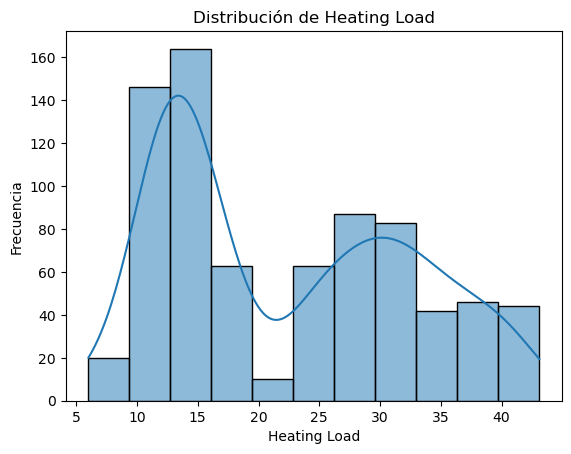

In [6]:
plt.figure()
sns.histplot(y, kde=True)
plt.title("Distribución de Heating Load")
plt.xlabel("Heating Load")
plt.ylabel("Frecuencia")
plt.show()

Matriz de correlación

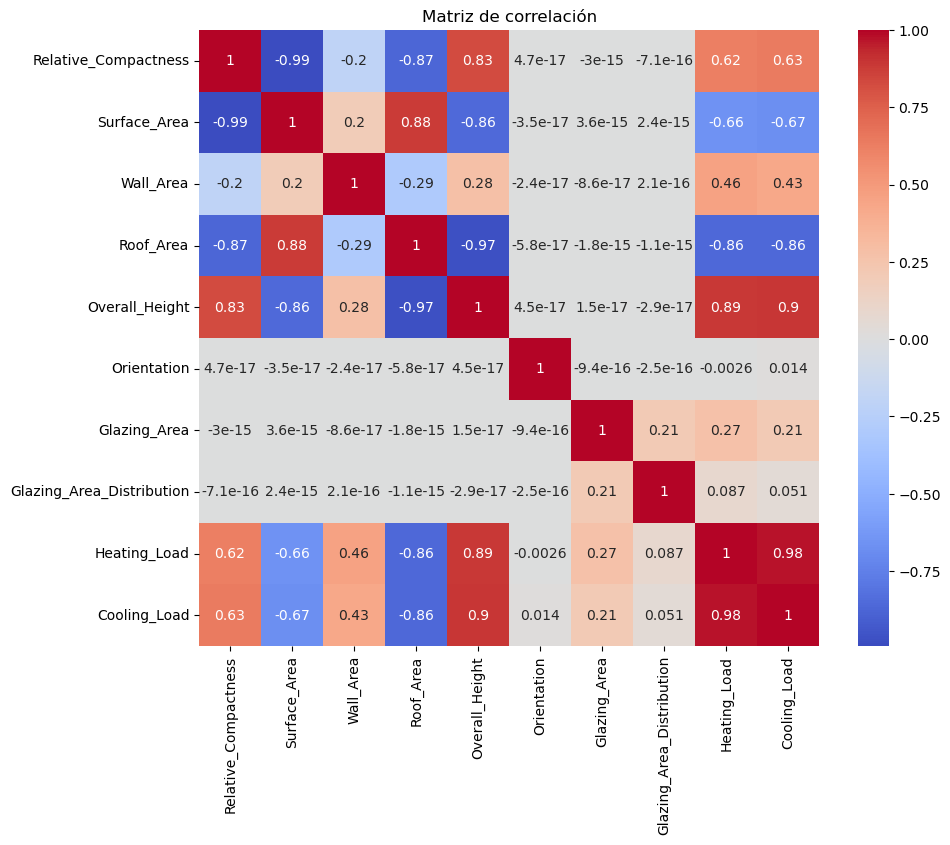

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

Análisis de relaciones individuales
Compactación relativa vs Carga de calefacción

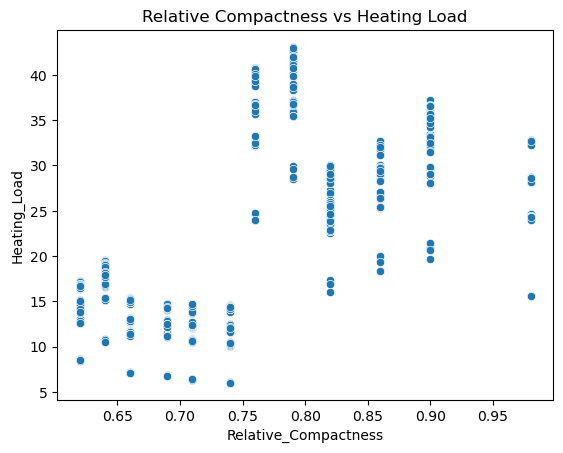

In [8]:
plt.figure()
sns.scatterplot(x=df["Relative_Compactness"], y=y)
plt.title("Relative Compactness vs Heating Load")
plt.show()

Altura del edificio vs Carga de calefacción

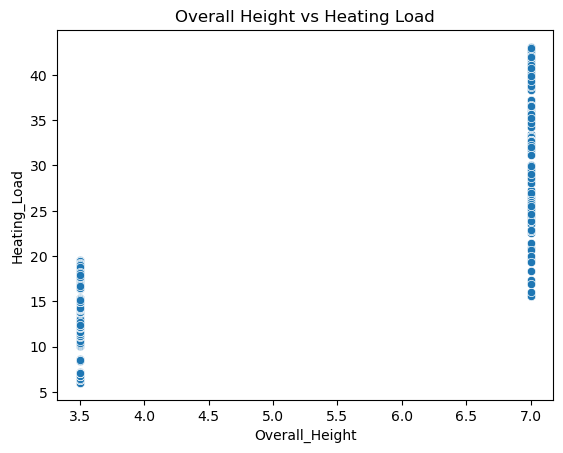

In [9]:
plt.figure()
sns.scatterplot(x=df["Overall_Height"], y=y)
plt.title("Overall Height vs Heating Load")
plt.show()

Modelado de los datos
Separación en conjuntos de entrenamiento y prueba

Se utiliza el 80% de los datos para entrenamiento y el 20% para prueba.


In [12]:
from sklearn.model_selection import train_test_split

In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Entrenamiento del modelo de regresión lineal

In [14]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predicción sobre el conjunto de prueba

In [15]:
y_pred = model.predict(X_test)

Evaluación del modelo

In [18]:

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2, mse, rmse


(0.9121840951546909, 9.15318785520276, np.float64(3.0254235827736187))

Interpretación de los resultados
El modelo de regresión lineal obtuvo un coeficiente de determinación (R²) de aproximadamente 0.91, lo que indica que explica una alta proporción de la variabilidad de la carga de calefacción.
El error cuadrático medio y su raíz muestran que el desvío promedio de las predicciones es relativamente bajo, lo que sugiere un buen desempeño del modelo. En conjunto, estos resultados indican que la regresión lineal es una técnica adecuada para predecir la carga de calefacción a partir de las características geométricas y de diseño del edificio.

Comparación entre valores reales y predichos

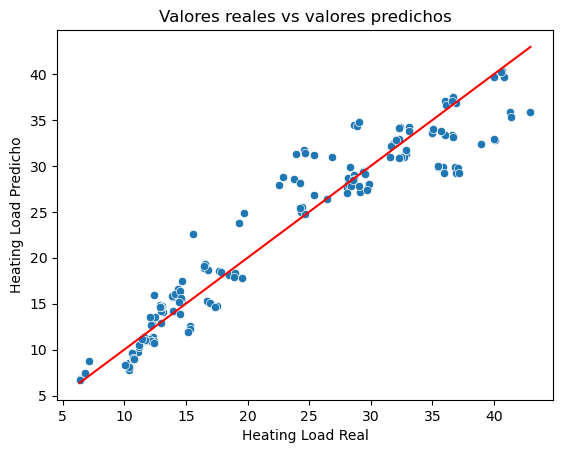

In [19]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.scatterplot(x=y_test, y=y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Heating Load Real")
plt.ylabel("Heating Load Predicho")
plt.title("Valores reales vs valores predichos")
plt.show()


Este gráfico permite visualizar el grado de ajuste del modelo, observándose que la mayoría de los puntos se distribuyen cercanos a la línea de referencia.

Conclusión
A partir del análisis exploratorio y del modelado realizado, se concluye que las características geométricas y de diseño del edificio influyen de manera significativa en la carga de calefacción.
El modelo de regresión lineal utilizado presenta un buen desempeño predictivo, por lo que resulta una técnica adecuada como primer enfoque para este tipo de problemas relacionados con la eficiencia energética.